# Customer Segmentation

## RFM SEGMENTATION

### Import library

In [103]:
import pandas as pd
import pyodbc
import datetime as dt
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

### 1.Import data customer Sales Recency, Frequency, Monetary

In [ ]:

conn = pyodbc.connect(driver = "SQL Server",
                      server='******',
                      database='******',
                      uid='******',pwd='******')
############################ CUSTOMER ##########################################
query_customer= """
SELECT MAIN_IDENTIFIER_NO
        ,COALESCE(RECENCY,180) AS RECENCY
        ,COALESCE(FREQUENCY,0) AS FREQUENCY
        ,COALESCE(MONETARY,0) AS MONETARY
FROM customer AS CUST
LEFT JOIN (SELECT RWD_CARD_NO
            ,MAX(BILLING_DATE) AS LAST_DATE
            ,DATEDIFF(DAY,MAX(BILLING_DATE),'2025-06-30')+1 AS RECENCY
            ,COUNT(DISTINCT BILLING_DATE) AS FREQUENCY
            ,SUM(NET_ITEM_AMT) AS MONETARY
            FROM billing
            WHERE  BILLING_DATE BETWEEN '2025-01-01' AND '2025-06-30' AND RWD_CARD_NO IS NOT NULL
            GROUP BY RWD_CARD_NO) AS SALES_6M
ON CUST.MAIN_IDENTIFIER_NO = RWD_CARD_NO
WHERE MAIN_IDENTIFIER_NO IS NOT NULL AND CUS_STATUS = 'A' AND RWD_CARD_NO IS NOT NULL AND MONETARY > 0
"""

BILLING_R = pd.read_sql_query(query_customer, conn)

C:\Users\Soul\AppData\Local\Temp\ipykernel_1524\3332176992.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  BILLING_R = pd.read_sql_query(query_customer, conn)


In [105]:
BILLING = BILLING_R
BILLING = BILLING.set_index('MAIN_IDENTIFIER_NO')
BILLING.head()

,RECENCY,FREQUENCY,MONETARY
MAIN_IDENTIFIER_NO,,,
1054480001,55,1,170.00
1061733106,149,1,10990.00
1009539931,57,1,2281.65
1024927318,17,12,42746.59
1091917522,136,1,4556.00


### 2.RECENCY, FEQUENCY, MONETARY to Quartile RFM

In [106]:
## Recency
r_labels = list(range(4, 0, -1))
r_quartiles = pd.qcut(BILLING['RECENCY'], 4, labels=r_labels)
BILLING['R'] = r_quartiles.astype(int)

## FREQUENCY
f_labels = range(1,5)
m_quartiles = pd.cut(BILLING['FREQUENCY'], 4, labels=f_labels)
BILLING['F'] = m_quartiles.astype(int)

## MONETARY
m_labels = range(1, 5)
m_quartiles = pd.cut(BILLING['MONETARY'], 4, labels=m_labels)
BILLING['M'] = m_quartiles.astype(int)


BILLING.head()

,RECENCY,FREQUENCY,MONETARY,R,F,M
MAIN_IDENTIFIER_NO,,,,,,
1054480001,55,1,170.00,3,1,1
1061733106,149,1,10990.00,1,1,1
1009539931,57,1,2281.65,2,1,1
1024927318,17,12,42746.59,4,1,1
1091917522,136,1,4556.00,1,1,1


### 3.Build RFM segment and RFM score

In [107]:
def join_rfm(x): return str(x['R']) + str(x['F']) + str(x['M'])
BILLING['RFM_SEGMENT'] = BILLING.apply(join_rfm, axis=1)
BILLING['RFM_SCORE'] = BILLING[['R','F','M']].sum(axis=1)

BILLING.head()

,RECENCY,FREQUENCY,MONETARY,R,F,M,RFM_SEGMENT,RFM_SCORE
MAIN_IDENTIFIER_NO,,,,,,,,
1054480001,55,1,170.00,3,1,1,3.01.01.0,5
1061733106,149,1,10990.00,1,1,1,1.01.01.0,3
1009539931,57,1,2281.65,2,1,1,2.01.01.0,4
1024927318,17,12,42746.59,4,1,1,4.01.01.0,6
1091917522,136,1,4556.00,1,1,1,1.01.01.0,3


### 4.Summary metrics per RFM score

In [108]:
BILLING.groupby('RFM_SCORE').agg({
'RECENCY': 'mean',
'FREQUENCY': 'mean',
'MONETARY': ['mean', 'count'] }).round(1)

RECENCY FREQUENCY    MONETARY        
             mean      mean        mean   count
RFM_SCORE                                      
3           141.5       1.5      6230.8  601167
4            78.5       2.3      9030.6  600829
5            37.3       3.4     12470.3  592379
6            10.0       5.8     22767.2  611565
7             3.9      57.8    339244.2    3546
8             2.3     101.3    969854.7     350
9             1.7     137.8   1826969.8      50
10            1.0     148.8   4511077.3      11
11            1.0     165.0   7636454.3       1
12            1.0     165.7  12711003.8       3

### 5.Grouping into named segments

In [109]:
def segment_me(df):
    if df['RFM_SCORE'] >= 9:
        return 'Gold'
    elif (df['RFM_SCORE'] >= 5) and (df['RFM_SCORE'] < 9):
        return 'Silver'
    else:
        return 'Bronze'
BILLING['SEGMENT'] = BILLING.apply(segment_me, axis=1)
BILLING.groupby('SEGMENT').agg({
'RECENCY': 'mean',
'FREQUENCY': 'mean',
'MONETARY': ['mean', 'count']}).round(1)

RECENCY FREQUENCY   MONETARY         
           mean      mean       mean    count
SEGMENT                                      
Bronze    110.0       1.9     7630.3  1201996
Gold        1.5     141.4  2872920.1       65
Silver     23.4       4.8    18920.7  1207840

## K-MEAN

### 1.Check distribution

In [110]:
BILLING.head()

,RECENCY,FREQUENCY,MONETARY,R,F,M,RFM_SEGMENT,RFM_SCORE,SEGMENT
MAIN_IDENTIFIER_NO,,,,,,,,,
1054480001,55,1,170.00,3,1,1,3.01.01.0,5,Silver
1061733106,149,1,10990.00,1,1,1,1.01.01.0,3,Bronze
1009539931,57,1,2281.65,2,1,1,2.01.01.0,4,Bronze
1024927318,17,12,42746.59,4,1,1,4.01.01.0,6,Silver
1091917522,136,1,4556.00,1,1,1,1.01.01.0,3,Bronze


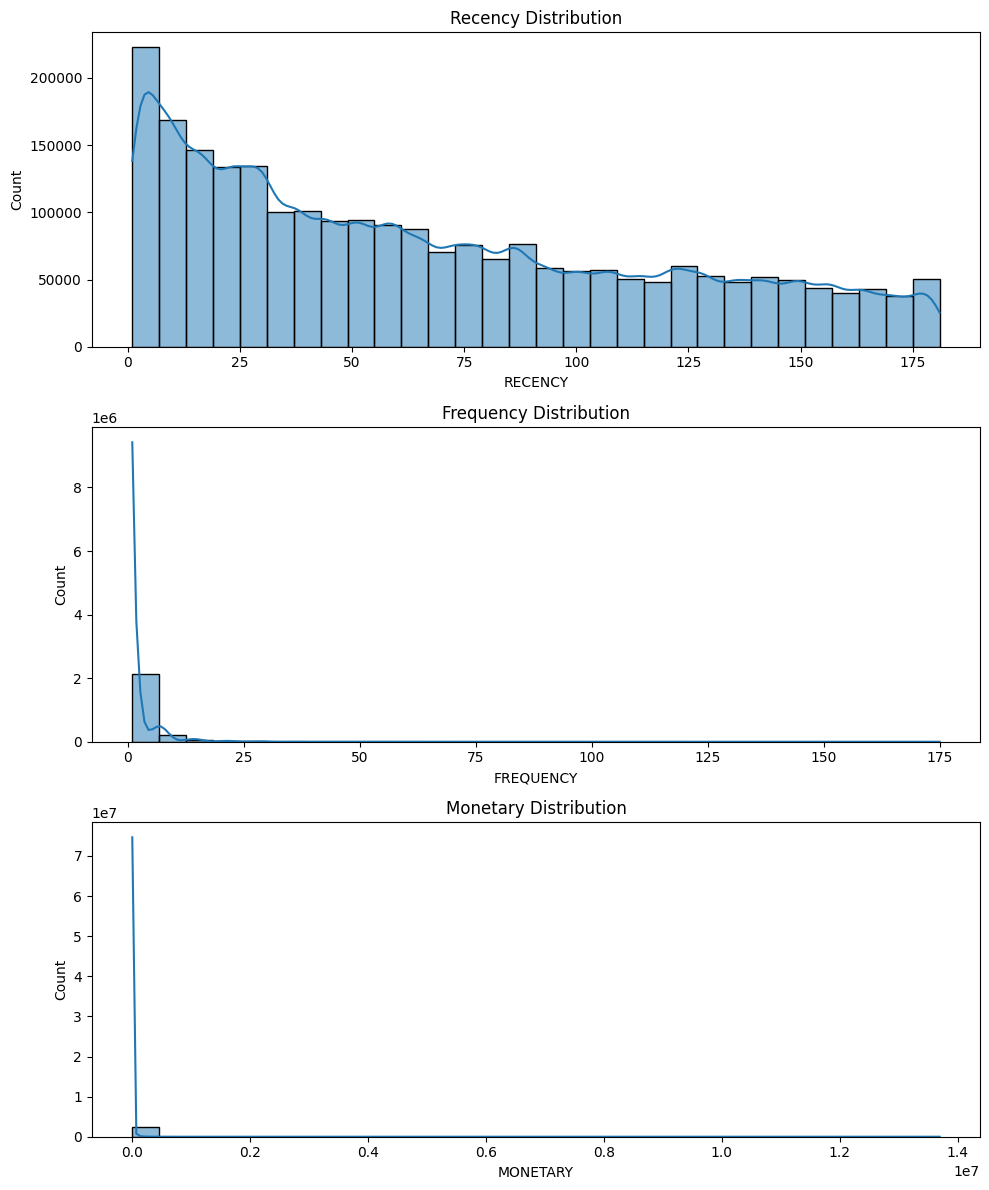

In [111]:
plt.figure(figsize=(10, 12))

# Recency
plt.subplot(3, 1, 1)
sns.histplot(BILLING['RECENCY'], kde=True, bins=30)
plt.title('Recency Distribution')

# Frequency
plt.subplot(3, 1, 2)
sns.histplot(BILLING['FREQUENCY'], kde=True, bins=30)
plt.title('Frequency Distribution')

# Monetary
plt.subplot(3, 1, 3)
sns.histplot(BILLING['MONETARY'], kde=True, bins=30)
plt.title('Monetary Distribution')

plt.tight_layout()
plt.show()

### 2.Transformations to manage skewness

In [112]:
BILLING_RFM = BILLING[['RECENCY','FREQUENCY','MONETARY']]
BILLING_RFM.head()

,RECENCY,FREQUENCY,MONETARY
MAIN_IDENTIFIER_NO,,,
1054480001,55,1,170.00
1061733106,149,1,10990.00
1009539931,57,1,2281.65
1024927318,17,12,42746.59
1091917522,136,1,4556.00


In [113]:
# Unskew the data
BILLING_LOG = np.log(BILLING_RFM)

# Initialize a standard scaler and fit it
scaler = StandardScaler()
BILLING_NORMALIZED = scaler.fit(BILLING_LOG)

# Scale and center the data
BILLING_NORMALIZED = scaler.transform(BILLING_LOG)

# Create a pandas DataFrame
BILLING_NORMALIZED = pd.DataFrame(data=BILLING_NORMALIZED, index=BILLING_RFM.index, columns=BILLING_RFM.columns)

BILLING_NORMALIZED

,RECENCY,FREQUENCY,MONETARY
MAIN_IDENTIFIER_NO,,,
1054480001,0.247717,-0.927313,-1.775261
1061733106,1.072229,-0.927313,0.671870
1009539931,0.277267,-0.927313,-0.250930
1024927318,-0.723649,2.046794,1.469182
1091917522,0.996702,-0.927313,0.155001
...,...,...,...
1096628621,0.247717,-0.097707,0.244233
1036282309,0.291655,0.731899,-0.268598
1011760673,-1.011808,1.561505,0.692262


### 3.Normal Distribution

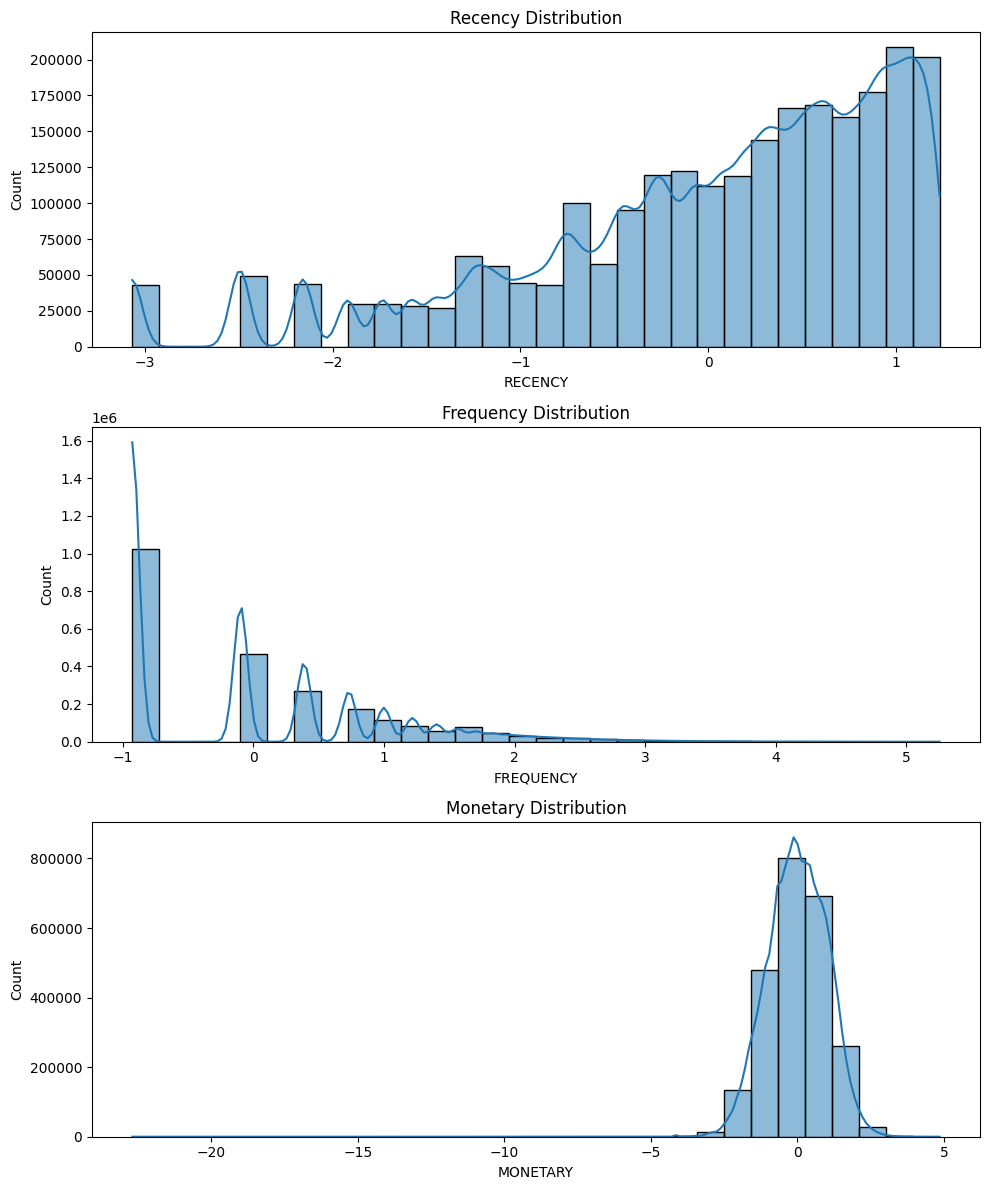

In [114]:
plt.figure(figsize=(10, 12))

# Recency
plt.subplot(3, 1, 1)
sns.histplot(BILLING_NORMALIZED['RECENCY'], kde=True, bins=30)
plt.title('Recency Distribution')

# Frequency
plt.subplot(3, 1, 2)
sns.histplot(BILLING_NORMALIZED['FREQUENCY'], kde=True, bins=30)
plt.title('Frequency Distribution')

# Monetary
plt.subplot(3, 1, 3)
sns.histplot(BILLING_NORMALIZED['MONETARY'], kde=True, bins=30)
plt.title('Monetary Distribution')

plt.tight_layout()
plt.show()

### 4.Choosing the number of clusters by Elbow criterion method

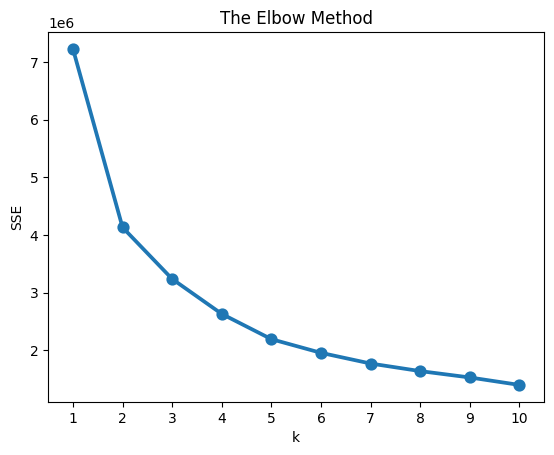

In [115]:
# Fit KMeans and calculate SSE for each *k*
sse = {}
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(BILLING_NORMALIZED)
    sse[k] = kmeans.inertia_
plt.title('The Elbow Method')
plt.xlabel('k'); plt.ylabel('SSE')
sns.pointplot(x=list(sse.keys()), y=list(sse.values()))
plt.show()

#### k = 3

### 5.Summary statistics of each cluster

In [116]:
# K = 3
kmeans = KMeans(n_clusters=3, random_state=1)
kmeans.fit(BILLING_NORMALIZED)
cluster_labels = kmeans.labels_

BILLING_RFM_K3 = BILLING_RFM.assign(CLUSTER = cluster_labels)
BILLING_RFM_K3.groupby(['CLUSTER']).agg({
'RECENCY': 'mean',
'FREQUENCY': 'mean',
'MONETARY': ['mean', 'count'],
}).round(0)


RECENCY FREQUENCY MONETARY        
           mean      mean     mean   count
CLUSTER                                   
0          87.0       1.0   1028.0  930397
1          15.0       8.0  34363.0  582147
2          79.0       2.0  12537.0  897357

### 6.Prepare data for a snake plot

In [117]:
BILLING_NORMALIZED.head()

,RECENCY,FREQUENCY,MONETARY
MAIN_IDENTIFIER_NO,,,
1054480001,0.247717,-0.927313,-1.775261
1061733106,1.072229,-0.927313,0.671870
1009539931,0.277267,-0.927313,-0.250930
1024927318,-0.723649,2.046794,1.469182
1091917522,0.996702,-0.927313,0.155001


In [118]:
BILLING_NORMALIZED = pd.DataFrame(BILLING_NORMALIZED,
index=BILLING_RFM.index,
columns=BILLING_RFM.columns)
BILLING_NORMALIZED['CLUSTER'] = BILLING_RFM_K3['CLUSTER']

BILLING_MELT = pd.melt(BILLING_NORMALIZED.reset_index(),
id_vars=['MAIN_IDENTIFIER_NO', 'CLUSTER'],
value_vars=['RECENCY','FREQUENCY','MONETARY'],
var_name='ATTRIBUTE',
value_name='VALUE')

BILLING_MELT.head()

,MAIN_IDENTIFIER_NO,CLUSTER,ATTRIBUTE,VALUE
0,1054480001,0,RECENCY,0.247717
1,1061733106,2,RECENCY,1.072229
2,1009539931,0,RECENCY,0.277267
3,1024927318,1,RECENCY,-0.723649
4,1091917522,2,RECENCY,0.996702


### 7. Visualize a snake plot

<Axes: title={'center': 'Snake plot of standardized variables'}, xlabel='ATTRIBUTE', ylabel='VALUE'>

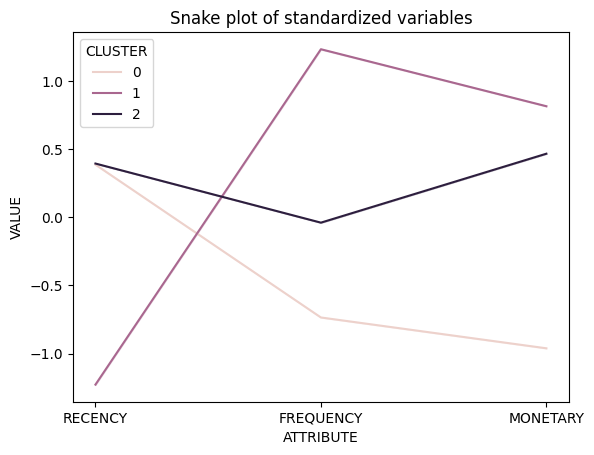

In [119]:
plt.title('Snake plot of standardized variables')
sns.lineplot(x="ATTRIBUTE", y="VALUE", hue='CLUSTER', data=BILLING_MELT)

### 8.Analyze and plot relative importance

In [120]:
BILLING_RFM_K3

,RECENCY,FREQUENCY,MONETARY,CLUSTER
MAIN_IDENTIFIER_NO,,,,
1054480001,55,1,170.00,0
1061733106,149,1,10990.00,2
1009539931,57,1,2281.65,0
1024927318,17,12,42746.59,1
1091917522,136,1,4556.00,2
...,...,...,...,...
1096628621,55,2,5304.00,2
1036282309,58,4,2214.00,2
1011760673,12,8,11378.50,1


In [121]:

# Calculate average RFM values for each cluster
cluster_avg = BILLING_RFM_K3.groupby(['CLUSTER']).mean() 

# Calculate average RFM values for the total customer population
population_avg = BILLING_RFM.mean()

# Calculate relative importance of cluster's attribute value compared to population
relative_imp = cluster_avg / population_avg - 1

# Print relative importance score rounded to 2 decimals
print(relative_imp.round(2))

         RECENCY  FREQUENCY  MONETARY
CLUSTER                              
0           0.30      -0.63     -0.92
1          -0.77       1.40      1.57
2           0.19      -0.26     -0.06


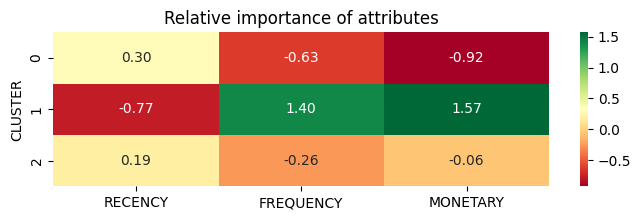

In [122]:
plt.figure(figsize=(8, 2))
plt.title('Relative importance of attributes')
sns.heatmap(data=relative_imp, annot=True, fmt='.2f', cmap='RdYlGn')
plt.show()